In [ ]:
%pip install "qiskit-terra==0.46.*"
from algos_optimized import *
from algos import generate_ising_hamiltonian, prepare_eigenstate_circuit
from qiskit.circuit import Parameter, Instruction

from qiskit.circuit import Parameter
τ = Parameter("τ")


Note: you may need to restart the kernel to use updated packages.


/Users/reyesfer/Desktop/qDriftExtraPolation/scripts/parameter_sweep/qft_qpe_qdrift/algos.py:134: SyntaxWarning: invalid escape sequence '\e'
  """


ImportError: Qiskit is installed in an invalid environment that has both Qiskit >=1.0 and an earlier version. You should create a new virtual environment, and ensure that you do not mix dependencies between Qiskit <1.0 and >=1.0. Any packages that depend on 'qiskit-terra' are not compatible with Qiskit 1.0 and will need to be updated. Qiskit unfortunately cannot enforce this requirement during environment resolution. See https://qisk.it/packaging-1-0 for more detail.

In [1]:
from qiskit.circuit.library import PauliEvolutionGate
gate = PauliEvolutionGate(SparsePauliOp.from_list([('X', 1.0)]), τ)
assert hasattr(gate, "assign_parameters")

ImportError: Qiskit is installed in an invalid environment that has both Qiskit >=1.0 and an earlier version. You should create a new virtual environment, and ensure that you do not mix dependencies between Qiskit <1.0 and >=1.0. Any packages that depend on 'qiskit-terra' are not compatible with Qiskit 1.0 and will need to be updated. Qiskit unfortunately cannot enforce this requirement during environment resolution. See https://qisk.it/packaging-1-0 for more detail.

In [6]:
H = generate_ising_hamiltonian(num_qubits=3,J=1.2, g=1)
H

SparsePauliOp(['ZZI', 'IZZ', 'ZIZ', 'XII', 'IXI', 'IIX'],
              coeffs=[-1.2+0.j, -1.2+0.j, -1.2+0.j, -1. +0.j, -1. +0.j, -1. +0.j])

In [8]:
cache_of_hamiltonian_terms_exponentials = make_pauli_gate_cache(H, placeholder_label='placeholder')
cache_of_hamiltonian_terms_exponentials

{'ZZI': Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[Parameter(tau)]),
 'IZZ': Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[Parameter(tau)]),
 'ZIZ': Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[Parameter(tau)]),
 'XII': Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[Parameter(tau)]),
 'IXI': Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[Parameter(tau)]),
 'IIX': Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[Parameter(tau)]),
 'placeholder': Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[Parameter(tau)])}

In [41]:
# binding parameters
tauuu = 10
bound = cache_of_hamiltonian_terms_exponentials["IIX"]
bound

Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[Parameter(tau)])

In [42]:
bound.assign_parameters({bound.tau: tauuu})


AttributeError: 'PauliEvolutionGate' object has no attribute 'assign_parameters'

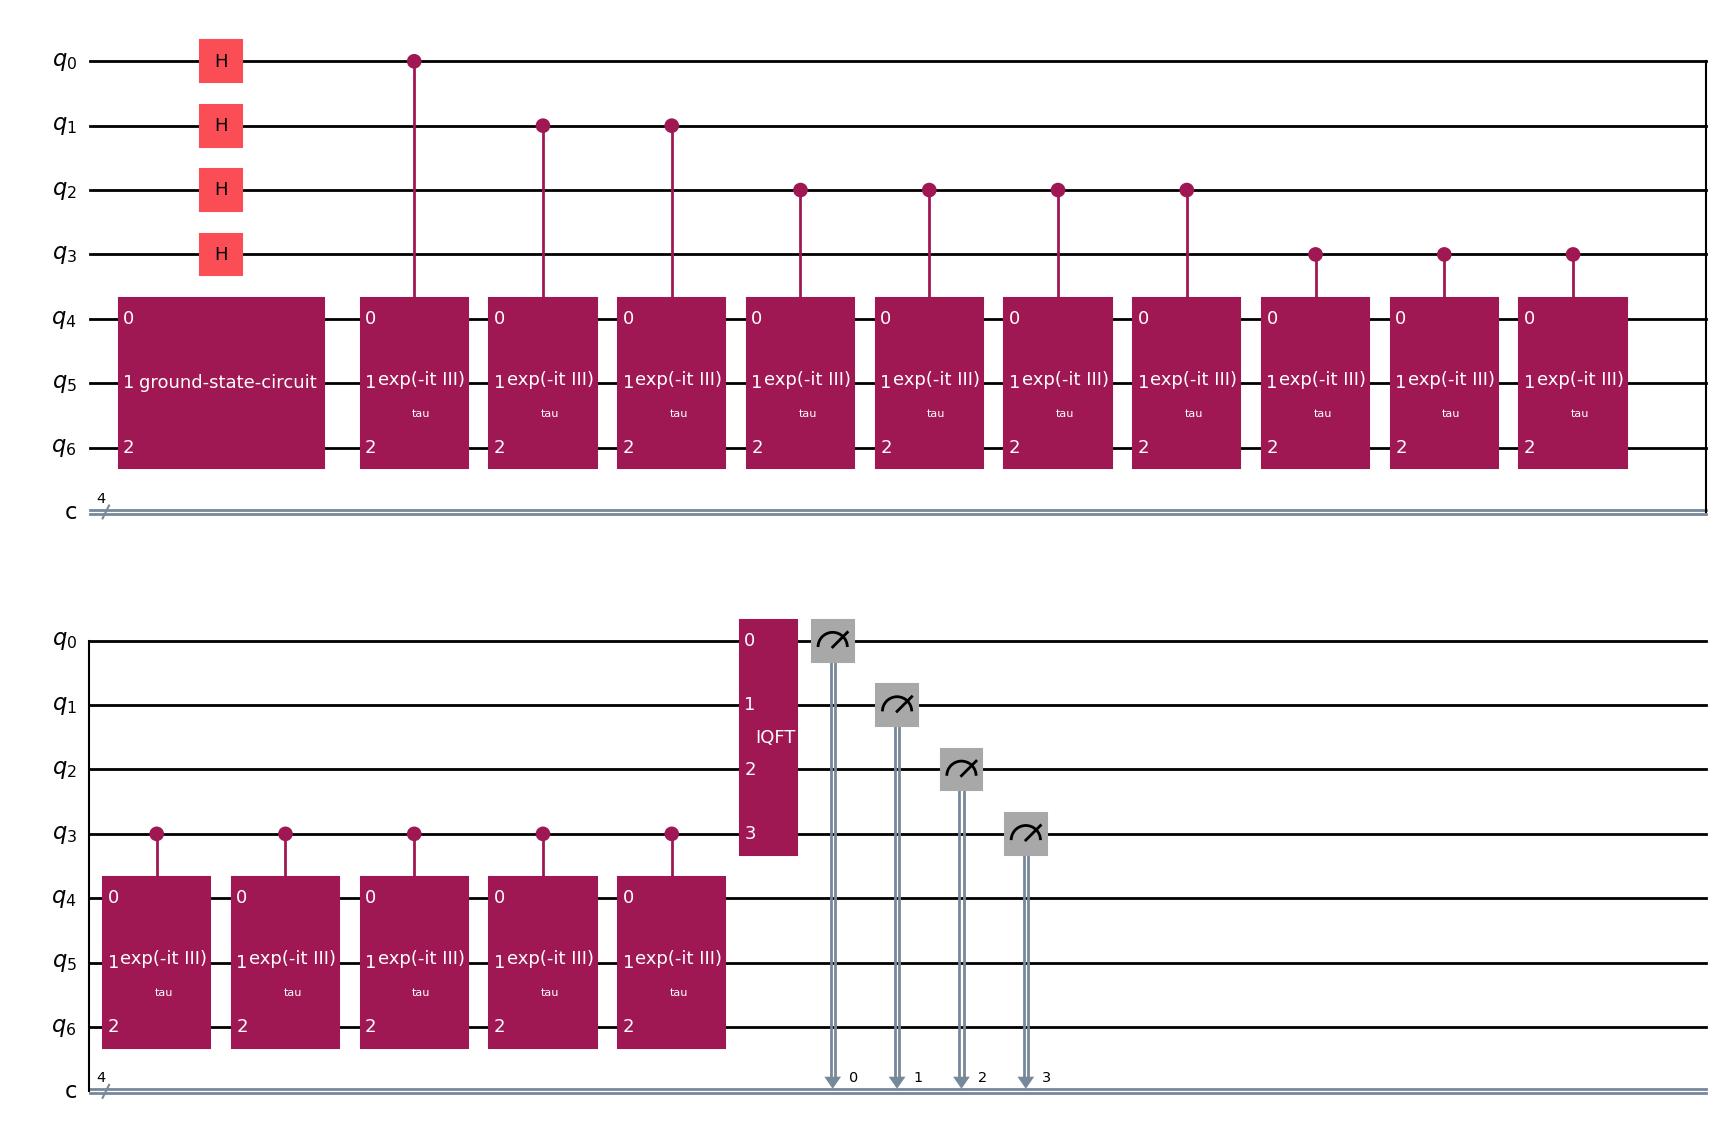

In [ ]:
NUM_ANCILLA = 4
NUM_SYSTEM = H.num_qubits
eigenvalues, eigenvectors = np.linalg.eigh(H.to_matrix())
ground_state = eigenvectors[:, np.argmin(eigenvalues)]
ground_state_circuit = prepare_eigenstate_circuit(ground_state)
ground_state_circuit.name = "ground-state-circuit"


template_qc = build_template_circuit(n_anc=NUM_ANCILLA, n_sys=NUM_SYSTEM, placeholder_label='placeholder', eigenvalue_circuit=ground_state_circuit, gate_cache=cache_of_hamiltonian_terms_exponentials)
template_qc.draw("mpl")

In [ ]:
# build a concrete circuit with qdrift
from traceback import print_tb

from matplotlib.pylab import rand


rng = np.random.default_rng(42)
PMF = np.abs(H.coeffs) / np.abs(H.coeffs).sum()
t = 0.1

template_instance = template_qc.copy()
randomly_drawn_samples = rng.choice(H.paulis.to_labels(), size=2**NUM_ANCILLA - 1, p=PMF)
randomly_drawn_samples = iter(randomly_drawn_samples)
print("Randomly drawn samples:", randomly_drawn_samples)
for instruction in template_instance.data:
    print(instruction)
    # replace the placeholder label with the drawn sample inplace
    if "placeholder" in instruction.operation.name:
        drawn_sample_name = next(randomly_drawn_samples) # get the next drawn sample (more efficient than using a list)
        drawn_sample = cache_of_hamiltonian_terms_exponentials[drawn_sample_name]
        print(f"Sampled Pauli label: {drawn_sample_name}, which corresponds to the gate:")
        print(drawn_sample)
        
        print("Before:", instruction.operation)


Randomly drawn samples: <iterator object at 0x124506770>
CircuitInstruction(operation=Instruction(name='ground-state-circuit', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(7, "q"), index=4>, <Qubit register=(7, "q"), index=5>, <Qubit register=(7, "q"), index=6>), clbits=())
CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(7, "q"), index=0>,), clbits=())
CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(7, "q"), index=1>,), clbits=())
CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(7, "q"), index=2>,), clbits=())
CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(7, "q"), index=3>,), clbits=())
CircuitInstruction(operation=Instruction(name='ctrl-evolution-0-placeholder', num_qubits=4, num_clbits=0, params=